# Group 2

In [5]:
pip install opencv-python


   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/39.5 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/39.5 MB 7.7 MB/s eta 0:00:05
   ----- ---------------------------------- 5.0/39.5 MB 8.2 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/39.5 MB 7.2 MB/s eta 0:00:05
   ------- -------------------------------- 7.6/39.5 MB 7.5 MB/s eta 0:00:05
   --------- ------------------------------ 9.4/39.5 MB 7.6 MB/s eta 0:00:04
   ----------- ---------------------------- 11.5/39.5 MB 7.8 MB/s eta 0:00:04
   ------------ --------------------------- 12.6/39.5 MB 7.5 MB/s eta 0:00:04
   ------------- -------------------------- 13.4/39.5 MB 7.1 MB/s eta 0:00:04
   -------------- ------------------------- 14.7/39.5 MB 6.9 MB/s eta 0:00:04
   ---------------- ----------------------- 16.5/39.5 MB 7.1 MB/s eta 0:00:04
   ------------------ --------------------- 17.8/39.5 MB 7.1 MB/s eta 0:00:04

In [7]:
pip install tensorflow-gpu

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [44 lines of output]
      Traceback (most recent call last):
        File "c:\Users\kauth\anaconda3\Lib\site-packages\packaging\requirements.py", line 36, in __init__
          parsed = _parse_requirement(requirement_string)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\kauth\anaconda3\Lib\site-packages\packaging\_parser.py", line 62, in parse_requirement
          return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\kauth\anaconda3\Lib\site-packages\packaging\_parser.py", line 80, in _parse_requirement
          url, specifier, marker = _parse_requirement_details(tokenizer)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\kauth\anaconda3\Lib\site-packages\packaging\_parser.py"

In [8]:
pip install tensorflow

   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/376.0 MB 4.2 MB/s eta 0:01:30
   ---------------------------------------- 1.3/376.0 MB 3.7 MB/s eta 0:01:41
   ---------------------------------------- 1.8/376.0 MB 3.1 MB/s eta 0:02:03
   ---------------------------------------- 2.6/376.0 MB 3.0 MB/s eta 0:02:04
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.1/376.0 MB 3.2 MB/s eta 0:01:58
   ---------------------------------------- 3.7/376.0 MB 1.4 MB/s eta 0

In [12]:
# Import the necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
import os
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

# Data and Image Preprocessing - Clifford

In [38]:
# Define photos directory
photos_dir = r"C:\Users\kauth\OneDrive\Desktop\Loyalist College\Yelp_folder\yelp_photos\photos"


In [39]:
# Load the photos JSON file
photos_df = pd.read_json(r"C:\Users\kauth\OneDrive\Desktop\Loyalist College\Yelp_folder\yelp_photos\photos.json", lines=True)

In [40]:
# Load the business JSON file
business_df = pd.read_json(r"C:\Users\kauth\OneDrive\Desktop\Loyalist College\Yelp_folder\yelp_dataset\yelp_academic_dataset_business.json", lines=True)

In [41]:
# Check the head of the photos dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [42]:
# Check the info of the photos dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [43]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [44]:
# Check the head of the business dataframe
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


## Labels Distribution

In [45]:
# Function for label distribution
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    palette = plt.get_cmap('Set2').colors
    ax = sns.countplot(
        data=df,
        x='label',
        order=df['label'].value_counts().index,
        palette=palette
    )
    plt.title("Image Count per Label")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            int(height),
            ha="center"
        )

    plt.tight_layout()
    plt.show()

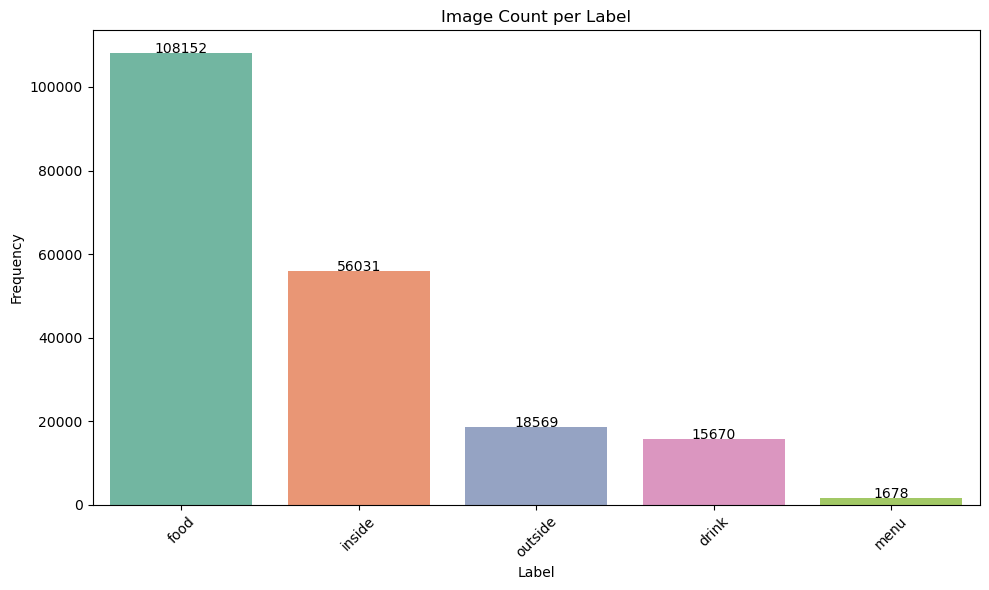

In [46]:
# Plot the distribution
plot_label_distribution(photos_df)

In [47]:
# Photo labels count
photos_df.groupby('label')['photo_id'].count()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: photo_id, dtype: int64

## Balance the Dataset by Undersampling

In [48]:
# Function to balance dataset
def balanced_sample(df, label_col='label'):
    # Find the minimum count across all labels
    min_count = df[label_col].value_counts().min()
    print(f" Sampling {min_count} images per label to ensure class balance.")

    # Perform undersampling for each class
    balanced_df = df.groupby(label_col).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

    print(f" Balanced DataFrame created with {len(balanced_df)} rows across {df[label_col].nunique()} classes.")
    return balanced_df

# Usage
photos_df_balanced = balanced_sample(photos_df)

 Sampling 1678 images per label to ensure class balance.
 Balanced DataFrame created with 8390 rows across 5 classes.


In [49]:
photos_df_balanced.to_csv('balanced_photos_df.csv')

In [50]:
#  Merge the two dataframes on 'business_id'
df = photos_df_balanced.merge(business_df, on="business_id", how="left")

In [51]:
df.shape

(8390, 17)

In [52]:
df.head()

,photo_id,business_id,caption,label,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink,Ruby Slipper - New Orleans,200 Magazine St,New Orleans,LA,70130,29.951025,-90.067394,4.5,5193,1,"{'NoiseLevel': ''loud'', 'Caters': 'False', 'B...","Restaurants, American (Traditional), American ...","{'Monday': '0:0-0:0', 'Tuesday': '7:30-14:0', ..."
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink,You Cha Cafe,1601 N Kings Hwy,Cherry Hill,NJ,08034,39.916220,-75.007034,4.5,44,1,"{'RestaurantsDelivery': 'True', 'WheelchairAcc...","Bubble Tea, Food, Restaurants, Cafes","{'Monday': '0:0-0:0', 'Tuesday': '11:30-18:0',..."
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink,Bardenay Restaurant & Distillery - Eagle,155 E Riverside St,Eagle,ID,83616,43.686635,-116.352242,4.0,351,1,"{'GoodForKids': 'True', 'BusinessParking': '{'...","Food, Cocktail Bars, Nightlife, Distilleries, ...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:0', ..."
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink,Signature Grill,3800 W Starr Pass Blvd,Tucson,AZ,85745,32.215561,-111.050749,3.5,105,1,"{'RestaurantsGoodForGroups': 'True', 'OutdoorS...","American (New), Restaurants, Southern, Breakfa...","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink,Brewforia Beer Market,"3030 E Overland Rd, Ste 100",Meridian,ID,83642,43.590798,-116.356710,4.0,52,0,"{'BusinessParking': '{'garage': False, 'street...","American (New), Beer, Wine & Spirits, Restaura...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


## Sample Images by Labels

In [53]:
# Function to show sample images
def show_sample_images(df, img_dir, num_samples=2):
    labels = df['label'].unique()
    n_labels = len(labels)
    fig, axes = plt.subplots(n_labels, num_samples, figsize=(15, 2 * n_labels))

    for i, label in enumerate(labels):
        sample_ids = df[df['label'] == label]['photo_id'].sample(num_samples, random_state=42).tolist()
        for j, photo_id in enumerate(sample_ids):
            img_path = os.path.join(img_dir, f"{photo_id}.jpg")
            try:
                img = Image.open(img_path)
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(label, fontsize=14)
            except Exception:
                # Optionally, you can clear the axis if image loading fails
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.axis('off')
    plt.tight_layout()
    plt.show()

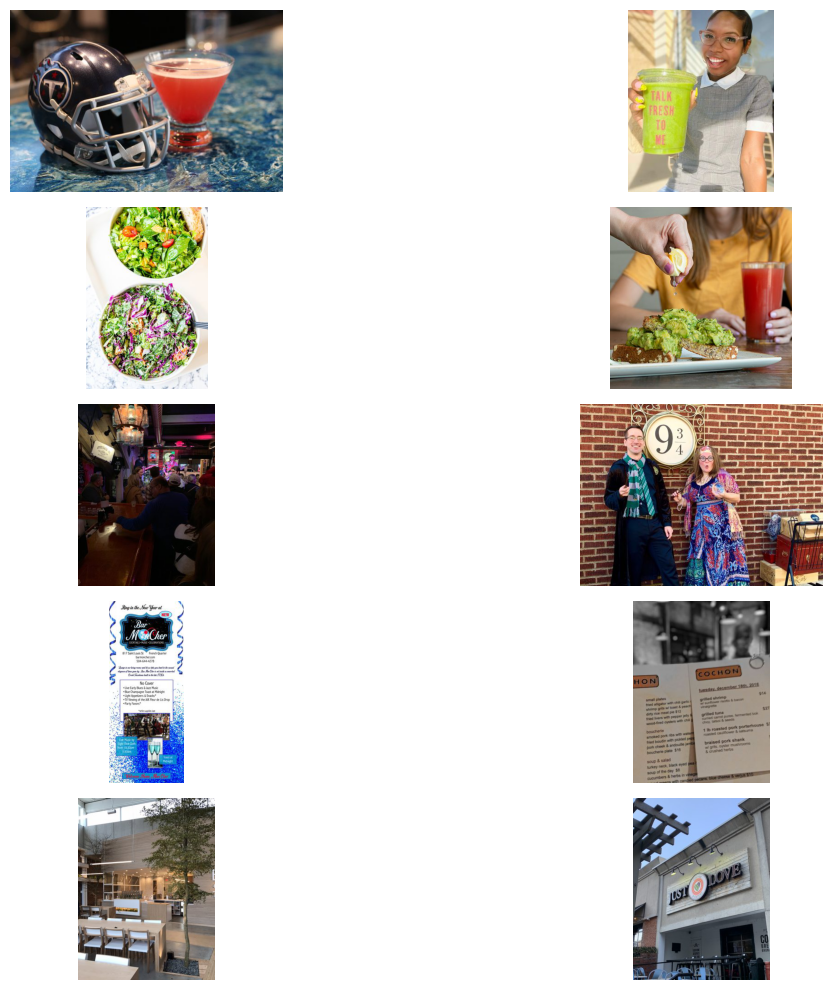

In [54]:
# Show samples
show_sample_images(df, photos_dir, num_samples=2)

## Image Shape Distribution

In [55]:
# Function for image shape distribution
def image_shape_analysis(df, img_dir, sample_size=1000):
    dims = []
    sample_paths = df['photo_id'].sample(sample_size, random_state=42).tolist()

    for photo_id in sample_paths:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = cv2.imread(img_path)
            dims.append(img.shape)
        except:
            continue

    dims = np.array(dims)
    height, width, channels = dims[:, 0], dims[:, 1], dims[:, 2]

    print(f"Average Dimensions: {np.mean(height):.2f} x {np.mean(width):.2f}")
    sns.histplot(height, bins=30, color='blue', kde=True, label='Height')
    sns.histplot(width, bins=30, color='green', kde=True, label='Width')
    plt.title("Image Height and Width Distribution")
    plt.legend()
    plt.show()

    print(f"Color Channels (should mostly be 3): {np.unique(channels, return_counts=True)}")

Average Dimensions: 391.26 x 434.02


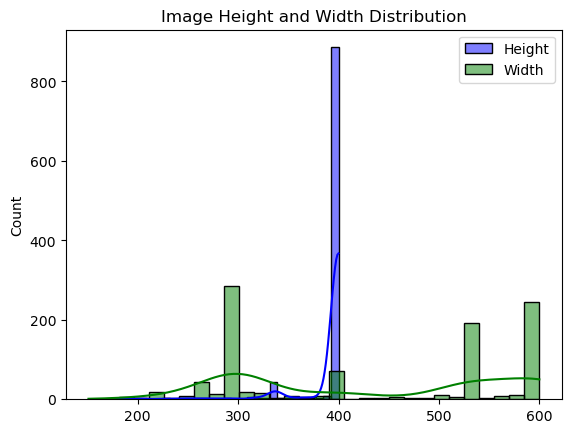

Color Channels (should mostly be 3): (array([3]), array([999], dtype=int64))


In [56]:
# Show image shape distribution
image_shape_analysis(df, img_dir=photos_dir)

## Text Analysis on Caption

In [57]:
# Function to analyze captions
def analyze_captions(df):
    caption_lengths = df['caption'].apply(lambda x: len(str(x).split()))
    print("Caption Word Count Summary:")
    print(caption_lengths.describe())
    
    sns.histplot(caption_lengths, bins=50, kde=True)
    plt.title("Caption Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

Caption Word Count Summary:
count    8390.000000
mean        2.425626
std         4.044971
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        31.000000
Name: caption, dtype: float64


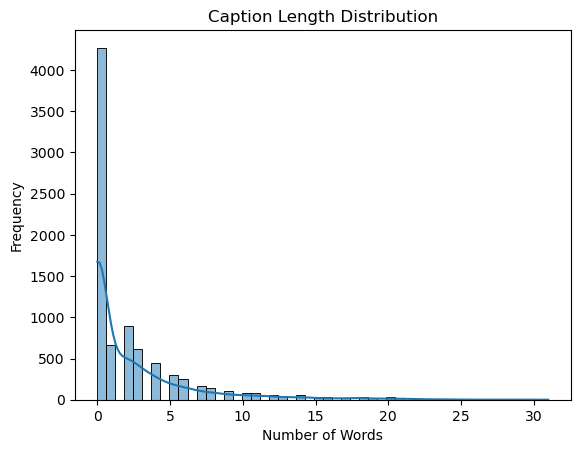

In [58]:
# Show analyzed captions
analyze_captions(df)

In [59]:
# Get image path
df['img_path'] = df['photo_id'].apply(lambda x: os.path.join(photos_dir, f"{x}.jpg"))

In [60]:
#  Check for image file existence
df['exists'] = df['img_path'].apply(os.path.exists)

In [61]:
df.shape

(8390, 19)

In [62]:
# Drop rows without image files
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

In [63]:
# Check info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8390 entries, 0 to 8389
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   photo_id      8390 non-null   object 
 1   business_id   8390 non-null   object 
 2   caption       8390 non-null   object 
 3   label         8390 non-null   object 
 4   name          8390 non-null   object 
 5   address       8390 non-null   object 
 6   city          8390 non-null   object 
 7   state         8390 non-null   object 
 8   postal_code   8390 non-null   object 
 9   latitude      8390 non-null   float64
 10  longitude     8390 non-null   float64
 11  stars         8390 non-null   float64
 12  review_count  8390 non-null   int64  
 13  is_open       8390 non-null   int64  
 14  attributes    8365 non-null   object 
 15  categories    8390 non-null   object 
 16  hours         8163 non-null   object 
 17  img_path      8390 non-null   object 
dtypes: float64(3), int64(2), obj

## Check for Corrupted images

In [64]:
# Function to check for corrupted images
def is_corrupted(photo_id, img_dir):
    img_path = os.path.join(img_dir, f"{photo_id}.jpg")
    try:
        img = Image.open(img_path)
        img.verify()
        return None  # Not corrupted
    except:
        return photo_id  # Corrupted

def check_corrupted_images(df, img_dir='train_photos', max_workers=16):
    corrupted = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(is_corrupted, pid, img_dir) for pid in df['photo_id']]

        for future in as_completed(futures):
            result = future.result()
            if result:
                corrupted.append(result)

    print(f" Finished checking. Total Corrupted Images: {len(corrupted)}")
    return corrupted

In [65]:
# Show corrupted images
corrupted_ids = check_corrupted_images(df, img_dir=photos_dir)

 Finished checking. Total Corrupted Images: 6


In [66]:
# Remove those rows from the DataFrame
initial_len = len(df)
df_cleaned = df[~df['photo_id'].isin(corrupted_ids)].reset_index(drop=True)

# Print the result
print(f" Cleaned DataFrame: {len(df_cleaned)} rows remaining (removed {initial_len - len(df_cleaned)} corrupted images)")

 Cleaned DataFrame: 8384 rows remaining (removed 6 corrupted images)


In [67]:
df = df_cleaned

In [68]:
df.to_csv('cleaned_photos_df.csv')

## Metadata Preprocessing

In [69]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]

In [70]:
# Keep only the selected metadata columns
df = df[selected_columns].copy()

print(" Filtered DataFrame shape:", df.shape)

 Filtered DataFrame shape: (8384, 9)


In [71]:
# Standardization function
def preprocess_metadata(df, scaler=None):
    df = df[['stars', 'review_count', 'is_open', 'latitude', 'longitude']].copy()
    if scaler is None:
        scaler = StandardScaler()
        return scaler.fit_transform(df), scaler
    else:
        return scaler.transform(df), scaler

### Label Encoding

In [72]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder Function
def encode_labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['label_encoded'] = encoder.fit_transform(df[label_col])
    return df, encoder

In [73]:
df, label_encoder = encode_labels(df, label_col='label')

# print df
print(df[['label', 'label_encoded']].head())

   label  label_encoded
0  drink              0
1  drink              0
2  drink              0
3  drink              0
4  drink              0


# Image Processing

In [74]:
# 1. Image Preprocessing
def preprocess_image(img_path, model_type='vgg', target_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    img = np.clip(img, 30, 220)

    if model_type == 'vgg':
        img = vgg_preprocess(img)
    elif model_type == 'effnet':
        img = effnet_preprocess(img)

    return img

In [75]:
# 2. Augmentation Function
def get_augmenter():
    return ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

In [76]:
# 3. Handling Train/Test Splits
def prepare_train_test(df, model_type='vgg'):
    X_img_paths = df['img_path'].values
    y = df['label_encoded'].values
    X_train_img_paths, X_test_img_paths, y_train, y_test = train_test_split(
        X_img_paths, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocess Images
    X_train_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_train_img_paths])
    X_test_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_test_img_paths])

    # Preprocess Metadata with shared scaler
    train_df = df[df['img_path'].isin(X_train_img_paths)]
    test_df = df[df['img_path'].isin(X_test_img_paths)]

    X_train_meta, scaler = preprocess_metadata(train_df)
    X_test_meta, _ = preprocess_metadata(test_df, scaler)

    return X_train_imgs, X_test_imgs, X_train_meta, X_test_meta, y_train, y_test

### Train_Test Split

In [77]:
# Run train-test preparation for EfficientNet Model
X_train_imgs_effnet, X_test_imgs_effnet, X_train_meta_effnet, X_test_meta_effnet, y_train_effnet, y_test_effnet = prepare_train_test(df, model_type='effnet')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_effnet.shape)
print("X_test_imgs shape:", X_test_imgs_effnet.shape)
print("X_train_meta shape:", X_train_meta_effnet.shape)
print("X_test_meta shape:", X_test_meta_effnet.shape)
print("y_train shape:", y_train_effnet.shape)
print("y_test shape:", y_test_effnet.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)




# Image Processing and Metadata Summary



## Data Loading and Initial Exploration

- Loaded `photos.json` and `business.json` into separate DataFrames.

- The `photos_df` contained 200,100 entries with 4 key columns:

  - `photo_id`, `business_id`, `caption`, and `label`.

- Found 5 unique labels: **inside**, **outside**, **drink**, **food**, and **menu**.



## Photo Label Distribution (Before Balancing)

| Label   | Count   |
|---------|---------|
| food    | 108,152 |
| inside  | 56,031  |
| outside | 18,569  |
| drink   | 15,670  |
| menu    | 1,678   |



- Identified a **class imbalance** in the photo labels.



## Data Balancing

- Balanced the dataset by **sampling 1,678 examples** from each label to match the minority class (`menu`).

- Final photo dataset contained **8,390 samples**.



## Merging Business Metadata

- Merged `photos_df` with `business_df` using `business_id` to append metadata.

- Resulting DataFrame had **17 columns**, including location, ratings, categories, etc.

- Added a new column, `img_path`, with full paths to image files.



## DataFrame Summary After Merging

- Total entries: **8,390**

- Included key metadata: `latitude`, `longitude`, `stars`, `review_count`, `is_open`, among others.

- Some fields like `caption` and `attributes` had missing values; `caption` was deemed unhelpful for modeling due to skewed distribution and sparsity.



## Cleaning and Preparation

- Found and dropped **6 corrupted image files**.

- Focused on non-null and useful metadata features:

  - `photo_id`, `business_id`, `label`, `latitude`, `longitude`, `stars`, `review_count`, `is_open`, and `img_path`.

- Applied **label encoding** to the labels (`food`, `inside`, etc.) converting them into numeric format.



## Metadata and Image Preprocessing



### Image Characteristics

- Examined image dimensions: heights were more consistent (mode ~900px) while widths showed a multi-modal distribution.

- Noted that image sizes varied widely and preprocessing would need to account for this.



### Metadata Processing

- Selected non-null and relevant numeric features for downstream modeling.

- Ensured consistency across training and test splits by applying the same scaling during preprocessing.



## Final Train-Test Dataset Statistics



### For VGG and EfficientNet Models

- **Training set**: 6,707 images and associated metadata.

- **Test set**: 1,677 images and associated metadata.

- Image dimensions standardized to **(224, 224, 3)**.

- Metadata features were **scaled** and limited to 5 selected columns.

- Labels encoded and stratified for balanced training/testing.



## Conclusion

- Created a clean, **balanced multimodal dataset** combining Yelp photo labels and business metadata.

- Implemented robust **image preprocessing**, including resizing, denoising, histogram equalization, and clipping.

- Ensured compatibility with **deep learning pipelines**, enabling effective modeling with VGG and EfficientNet architectures.

In [78]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model

In [79]:
# Inputs
img_input = Input(shape=(224, 224, 3), name='image_input')
meta_input = Input(shape=(5,), name='meta_input')  # stars, review_count, is_open, lat, long

# Pretrained EfficientNet
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=img_input)
base_model.trainable = False  # freeze base initially

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [80]:
# Image features
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

In [81]:
# Combine image and metadata
x = Concatenate()([x, meta_input])
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(5, activation='softmax')(x)  # 5 classes

In [82]:
# Final model
model = Model(inputs=[img_input, meta_input], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,222,760 (16.11 MB)

 Trainable params: 173,189 (676.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [87]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time


In [90]:
# 1. Set up your augmenter
augmenter = get_augmenter()

# 2. Apply augmentation manually (you can rerun this every epoch if you like)
X_train_augmented = np.array([
    augmenter.random_transform(img) for img in X_train_imgs_effnet
])

# 3. Callbacks for early stopping and learning rate adjustment
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.2)
]

# 4. Train the model directly using NumPy arrays
start_time = time.time()
history = model.fit(
    [X_train_augmented, X_train_meta_effnet],   # both inputs: images + metadata
    y_train_effnet,                              # labels
    batch_size=32,
    epochs=20,
    validation_data=([X_test_imgs_effnet, X_test_meta_effnet], y_test_effnet),
    callbacks=callbacks,
    verbose=1
)
end_time = time.time()
print(f"\n🕒 Training Time: {round((end_time - start_time)/60, 2)} minutes")

Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 205s 865ms/step - accuracy: 0.7256 - loss: 0.7526 - val_accuracy: 0.9207 - val_loss: 0.2407 - learning_rate: 0.0010
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 174s 827ms/step - accuracy: 0.8858 - loss: 0.3259 - val_accuracy: 0.9243 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 174s 829ms/step - accuracy: 0.8921 - loss: 0.3111 - val_accuracy: 0.9273 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 171s 813ms/step - accuracy: 0.9180 - loss: 0.2434 - val_accuracy: 0.9249 - val_loss: 0.2290 - learning_rate: 0.0010
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 169s 806ms/step - accuracy: 0.9169 - loss: 0.2279 - val_accuracy: 0.9332 - val_loss: 0.2148 - learning_rate: 0.0010
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 172s 820ms/step - accuracy: 0.9235 - loss: 0.2094 - val_accuracy: 0.9302 - val_loss: 0.2193 - learning_rate: 0.0010
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 169s 804ms/step - accura

In [ ]:
# Print final metrics from history
print("Training Metrics:")
for key in history.history:
    final_value = history.history[key][-1]
    print(f"{key}: {final_value:.4f}")

\ Training Metrics:
accuracy: 0.9463
loss: 0.1412
val_accuracy: 0.9320
val_loss: 0.2289
learning_rate: 0.0002


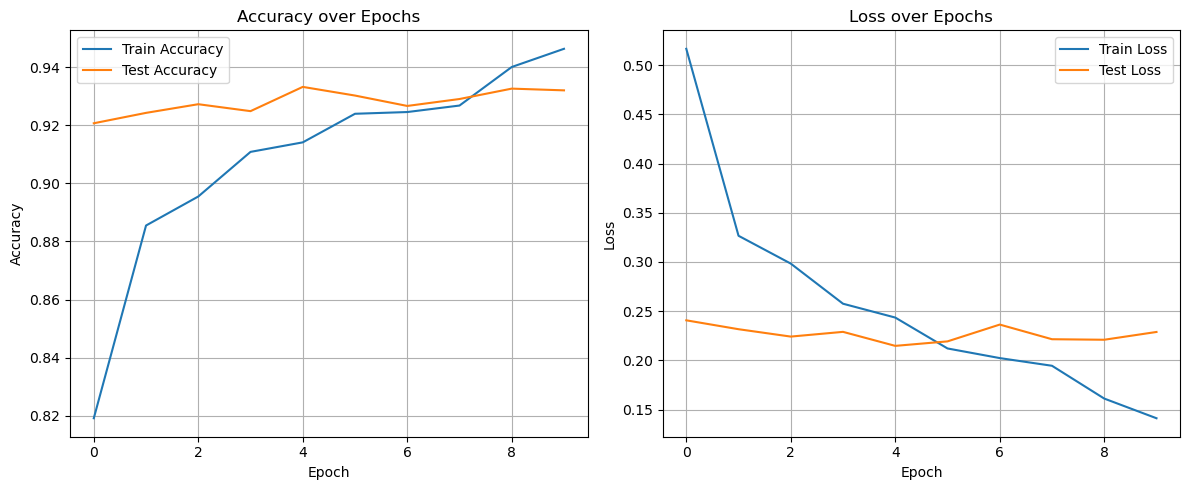

In [92]:
import matplotlib.pyplot as plt

# Set up plots
plt.figure(figsize=(12, 5))

# 1. Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 722ms/step


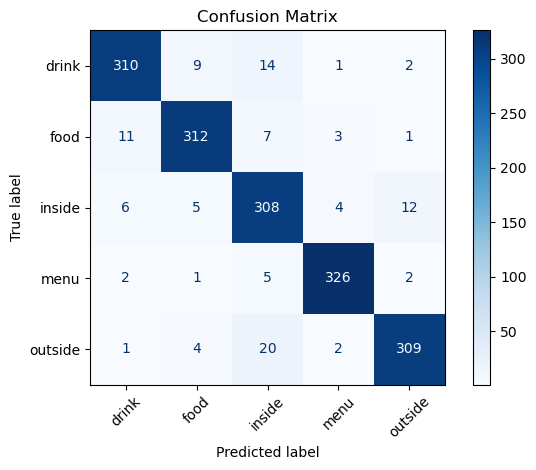

AUC Score (One-vs-Rest): 0.9927


In [93]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


# 1. Predict probabilities
y_pred_probs = model.predict([X_test_imgs_effnet, X_test_meta_effnet])

# 2. Get predicted class indices
y_pred = y_pred_probs.argmax(axis=1)

# 3. Confusion matrix
cm = confusion_matrix(y_test_effnet, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 4. AUC Score (One-vs-Rest)
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test_effnet, classes=np.arange(5))

auc_score = roc_auc_score(y_test_bin, y_pred_probs, multi_class="ovr")
print(f"AUC Score (One-vs-Rest): {round(auc_score, 4)}")


## Classification Report Baseline model

In [102]:
from sklearn.metrics import classification_report

# Classification report for initial model
report_initial = classification_report(
    y_test_effnet,
    y_pred,  # from initial model prediction in Part C
    target_names=label_encoder.classes_,
    digits=4
)

print("Classification Report (Initial Model):")
print(report_initial)


Classification Report (Initial Model):
              precision    recall  f1-score   support

       drink     0.9394    0.9226    0.9309       336
        food     0.9426    0.9341    0.9383       334
      inside     0.8701    0.9194    0.8940       335
        menu     0.9702    0.9702    0.9702       336
     outside     0.9479    0.9196    0.9335       336

    accuracy                         0.9332      1677
   macro avg     0.9340    0.9332    0.9334      1677
weighted avg     0.9341    0.9332    0.9334      1677



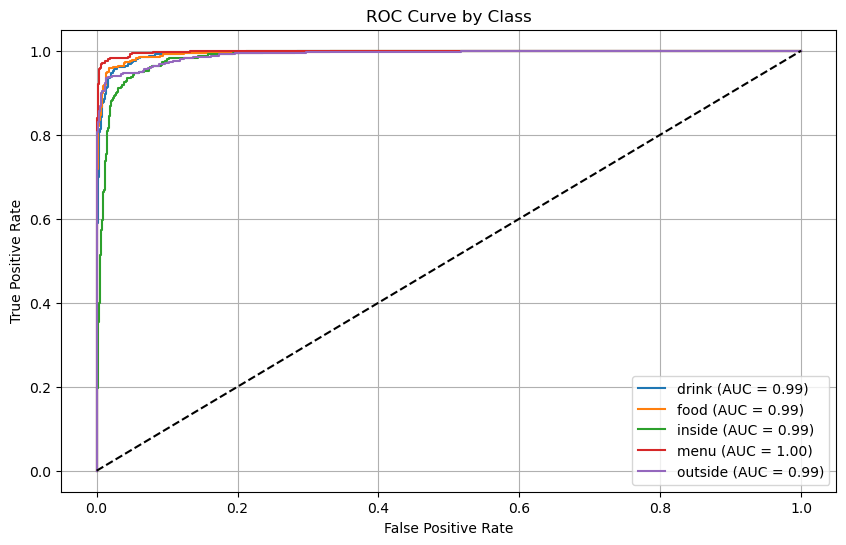

In [94]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(fpr[i], tpr[i], label=f'{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve by Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


## Fine Tuning

In [95]:
from tensorflow.keras.optimizers import Adam

# 1. Unfreeze top 20 layers 
for layer in base_model.layers[-20:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# 2. Re-compile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Re-augment training data
X_train_augmented = np.array([
    augmenter.random_transform(img) for img in X_train_imgs_effnet
])

# 4. Re-train model (fine-tuning)
fine_tune_history = model.fit(
    [X_train_augmented, X_train_meta_effnet],
    y_train_effnet,
    batch_size=32,
    epochs=10,
    validation_data=([X_test_imgs_effnet, X_test_meta_effnet], y_test_effnet),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.9033 - loss: 0.2646 - val_accuracy: 0.9320 - val_loss: 0.2133 - learning_rate: 1.0000e-05
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 186s 888ms/step - accuracy: 0.9152 - loss: 0.2432 - val_accuracy: 0.9314 - val_loss: 0.2110 - learning_rate: 1.0000e-05
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 184s 878ms/step - accuracy: 0.9174 - loss: 0.2290 - val_accuracy: 0.9350 - val_loss: 0.2077 - learning_rate: 1.0000e-05
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.9215 - loss: 0.2003 - val_accuracy: 0.9356 - val_loss: 0.2079 - learning_rate: 1.0000e-05
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 187s 889ms/step - accuracy: 0.9213 - loss: 0.2103 - val_accuracy: 0.9374 - val_loss: 0.2068 - learning_rate: 1.0000e-05
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 187s 890ms/step - accuracy: 0.9206 - loss: 0.2203 - val_accuracy: 0.9386 - val_loss: 0.2034 - learning_rate: 1.0000e-05
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 182s 8

In [96]:
# Print final metrics from fine-tuning
print("Fine-Tuning Metrics:")
for key in fine_tune_history.history:
    final_value = fine_tune_history.history[key][-1]
    print(f"{key}: {final_value:.4f}")


Fine-Tuning Metrics:
accuracy: 0.9362
loss: 0.1778
val_accuracy: 0.9392
val_loss: 0.2041
learning_rate: 0.0000


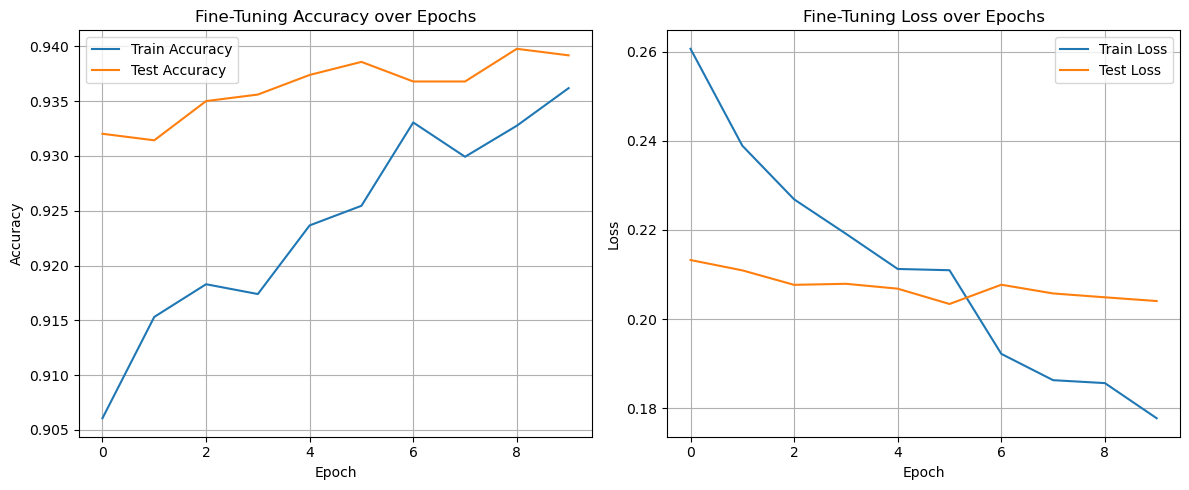

In [97]:
# Plot fine-tuning metrics only
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Test Accuracy')
plt.title('Fine-Tuning Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Test Loss')
plt.title('Fine-Tuning Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 630ms/step


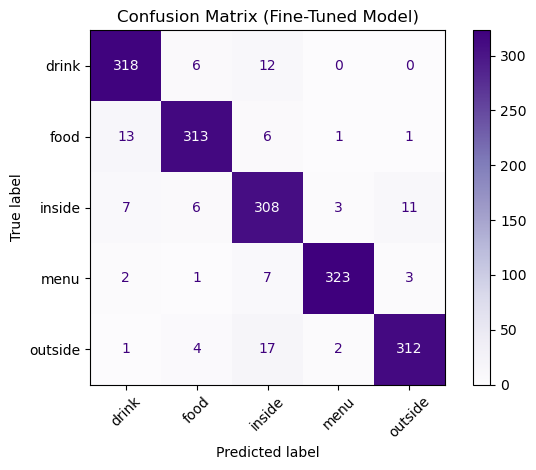

In [103]:
# Predict on test data using the fine-tuned model
y_finetune_probs = model.predict([X_test_imgs_effnet, X_test_meta_effnet])
y_finetune_pred = y_finetune_probs.argmax(axis=1)

# Confusion matrix
cm_ft = confusion_matrix(y_test_effnet, y_finetune_pred)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=label_encoder.classes_)
disp_ft.plot(cmap='Purples', xticks_rotation=45)
plt.title("Confusion Matrix (Fine-Tuned Model)")
plt.tight_layout()
plt.show()


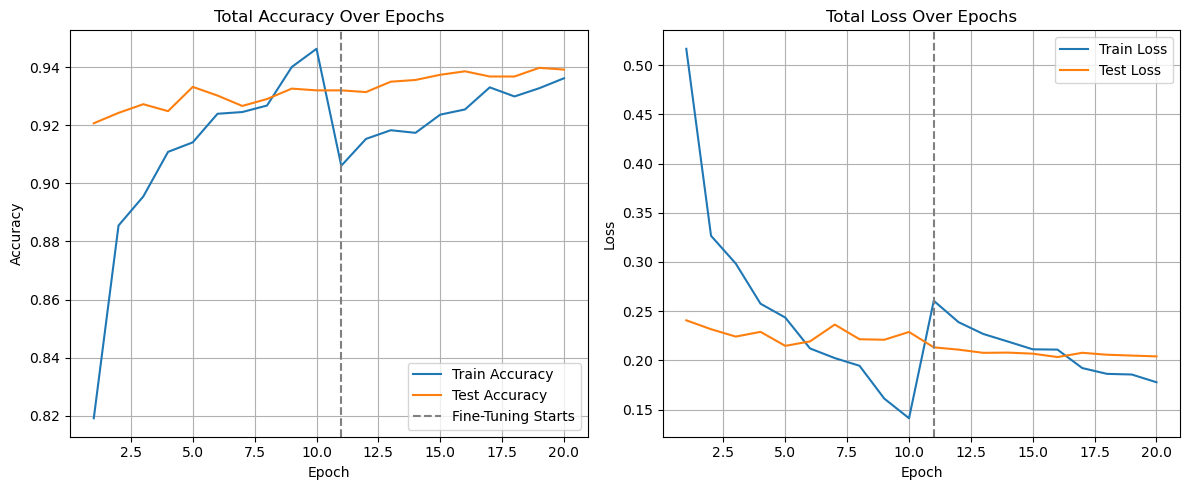

In [98]:
# Merge history and fine-tuning history
full_acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
full_val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
full_loss = history.history['loss'] + fine_tune_history.history['loss']
full_val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs_range = range(1, len(full_acc) + 1)
tune_start = len(history.history['accuracy']) + 1  # start of fine-tuning

# Plot full timeline
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, full_acc, label='Train Accuracy')
plt.plot(epochs_range, full_val_acc, label='Test Accuracy')
plt.axvline(x=tune_start, color='gray', linestyle='--', label='Fine-Tuning Starts')
plt.title('Total Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, full_loss, label='Train Loss')
plt.plot(epochs_range, full_val_loss, label='Test Loss')
plt.axvline(x=tune_start, color='gray', linestyle='--')
plt.title('Total Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [99]:
from tensorflow.keras.models import load_model
import pickle


# 1. Save initial model (after Part B)
model.save('efficientnet_initial.h5')         # HDF5 format
model.save('efficientnet_initial.keras')      # Native TF format

# 2. Save fine-tuned model (after Part E)
model.save('efficientnet_finetuned.h5')       # HDF5 format
model.save('efficientnet_finetuned.keras')    # Native TF format

# 3. Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(" Models and label encoder saved successfully.")


 Models and label encoder saved successfully.


## Confusion Metric fine tuning

## Fine Reprt

In [101]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_test_effnet,
    y_finetune_pred,
    target_names=label_encoder.classes_,
    digits=4
)

print("Classification Report (Fine-Tuned Model):")
print(report)


Classification Report (Fine-Tuned Model):
              precision    recall  f1-score   support

       drink     0.9326    0.9464    0.9394       336
        food     0.9485    0.9371    0.9428       334
      inside     0.8800    0.9194    0.8993       335
        menu     0.9818    0.9613    0.9714       336
     outside     0.9541    0.9286    0.9412       336

    accuracy                         0.9386      1677
   macro avg     0.9394    0.9386    0.9388      1677
weighted avg     0.9394    0.9386    0.9388      1677

